# Cancelaciones de Reservas Hoteleras
## ¿Las peticiones especiales son señal de compromiso real del huésped?

**Autora:** Yudy Marcela Cadena    
**Curso:** Programación y Análisis Reproducible de Datos  
**Fecha:** 9 de mayo del 2026 

---

Este notebook implementa un análisis completo y reproducible sobre las cancelaciones de reservas hoteleras, siguiendo el ciclo de vida completo del análisis de datos: desde la carga del dataset crudo hasta la generación de conclusiones accionables.

**Cómo reproducir:** Ejecutar todas las celdas en orden — `Kernel → Restart & Run All`.

---
## Sección 1 — Introducción y pregunta de análisis (10%)

### Dataset

| Atributo | Detalle |
|---|---|
| **Nombre** | Hotel Reservations Dataset |
| **Fuente** | Kaggle — Ahsan Raza |
| **URL** | https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset |
| **Licencia** | CC0 — Dominio Público |
| **Registros** | 36,275 |
| **Variables** | 19 |
| **Descarga** | Mayo 2025 |

El dataset contiene información de reservas hoteleras individuales, incluyendo características del grupo de viaje, el canal de reserva, el precio, y si la reserva fue o no cancelada.

### Pregunta de análisis

> **¿Existe una relación de dependencia estadística entre el número de peticiones especiales realizadas por un huésped y la probabilidad de cancelación de su reserva, y cómo modera el precio promedio de la habitación esta relación?**

### Hipótesis de trabajo

Un huésped que realiza peticiones especiales (tipo de habitación, almohadas, dieta especial, etc.) demuestra mayor inversión cognitiva y emocional en el viaje. Esta inversión actúa como un 'costo hundido psicológico' que reduce la probabilidad de cancelar. Adicionalmente, si el precio de la habitación es elevado, esta señal de compromiso podría ser aún más fuerte — o al contrario, el precio alto podría incentivar la cancelación en huéspedes price-sensitive.

**Esta pregunta es verificable con los datos** porque el dataset contiene exactamente las variables necesarias: `no_of_special_requests`, `avg_price_per_room` y `booking_status`.

---
## Sección 2 — Carga y exploración inicial (15%)

## Descripción del Dataset

El archivo contiene los atributos de las reservas de cada cliente. A continuación se presenta el diccionario de datos completo.

### Diccionario de Variables

| Variable | Descripción |
|:---|:---|
| `Booking_ID` | Identificador único de cada reserva |
| `no_of_adults` | Número de adultos |
| `no_of_children` | Número de niños |
| `no_of_weekend_nights` | Número de noches de fin de semana (sábado o domingo) que el huésped se hospedó o tiene reservadas |
| `no_of_week_nights` | Número de noches entre semana (lunes a viernes) que el huésped se hospedó o tiene reservadas |
| `type_of_meal_plan` | Tipo de plan de alimentación reservado por el cliente |
| `required_car_parking_space` | ¿El cliente requiere espacio de estacionamiento? (0 = No, 1 = Sí) |
| `room_type_reserved` | Tipo de habitación reservada por el cliente. Los valores están cifrados (codificados) por INN Hotels |
| `lead_time` | Número de días entre la fecha de reserva y la fecha de llegada |
| `arrival_year` | Año de la fecha de llegada |
| `arrival_month` | Mes de la fecha de llegada |
| `arrival_date` | Día del mes de llegada |
| `market_segment_type` | Segmento de mercado al que pertenece la reserva |
| `repeated_guest` | ¿El cliente es un huésped recurrente? (0 = No, 1 = Sí) |
| `no_of_previous_cancellations` | Número de reservas anteriores canceladas por el cliente antes de la reserva actual |
| `no_of_previous_bookings_not_canceled` | Número de reservas anteriores **no** canceladas por el cliente antes de la reserva actual |
| `avg_price_per_room` | Precio promedio por noche de la reserva; los precios son dinámicos (en euros) |
| `no_of_special_requests` | Número total de solicitudes especiales realizadas por el cliente (p. ej., piso alto, vista desde la habitación, etc.) |
| `booking_status` | Indicador de si la reserva fue cancelada o no *(variable objetivo)* |

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import statsmodels.api as sm
import warnings

plt.style.use('seaborn-v0_8-whitegrid')  # Aplica estilo 'seaborn' a los gráficos
sns.set_palette('husl')               # Establece una paleta de colores bonita

print('Librerías cargadas correctamente.')
print(f'pandas {pd.__version__} | numpy {np.__version__}')

Librerías cargadas correctamente.
pandas 3.0.2 | numpy 2.4.4


In [8]:
# ── Carga del dataset ──────────────────────────────────────────────────────────
DATA_PATH = '../data/raw/hotel_reservations.csv'

df_raw = pd.read_csv(DATA_PATH)

print(f'Dimensiones: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
df_raw.head(5)

Dimensiones: 36,275 filas × 19 columnas


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [9]:
# ── Tipos de variables y nulos ─────────────────────────────────────────────────
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  str    
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  str    
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  str    
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date              

**Nota**: Todas las columnas tienen count = 36,275 por lo que no se evidencian valores nulos (la limpieza de faltantes será mínima o nula.)

In [10]:
# ── Estadísticos descriptivos ──────────────────────────────────────────────────
df_raw.describe(include='all').round(2)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
count,36275,36275.00,36275.00,36275.00,36275.00,36275,36275.00,36275,36275.00,36275.00,36275.00,36275.00,36275,36275.00,36275.00,36275.00,36275.00,36275.00,36275
unique,36275,NaN,NaN,NaN,NaN,4,NaN,7,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,2
top,INN00001,NaN,NaN,NaN,NaN,Meal Plan 1,NaN,Room_Type 1,NaN,NaN,NaN,NaN,Online,NaN,NaN,NaN,NaN,NaN,Not_Canceled
freq,1,NaN,NaN,NaN,NaN,27835,NaN,28130,NaN,NaN,NaN,NaN,23214,NaN,NaN,NaN,NaN,NaN,24390
mean,NaN,1.84,0.11,0.81,2.20,NaN,0.03,NaN,85.23,2017.82,7.42,15.60,NaN,0.03,0.02,0.15,103.42,0.62,NaN
std,NaN,0.52,0.40,0.87,1.41,NaN,0.17,NaN,85.93,0.38,3.07,8.74,NaN,0.16,0.37,1.75,35.09,0.79,NaN
min,NaN,0.00,0.00,0.00,0.00,NaN,0.00,NaN,0.00,2017.00,1.00,1.00,NaN,0.00,0.00,0.00,0.00,0.00,NaN
25%,NaN,2.00,0.00,0.00,1.00,NaN,0.00,NaN,17.00,2018.00,5.00,8.00,NaN,0.00,0.00,0.00,80.30,0.00,NaN
50%,NaN,2.00,0.00,1.00,2.00,NaN,0.00,NaN,57.00,2018.00,8.00,16.00,NaN,0.00,0.00,0.00,99.45,0.00,NaN
75%,NaN,2.00,0.00,2.00,3.00,NaN,0.00,NaN,126.00,2018.00,10.00,23.00,NaN,0.00,0.00,0.00,120.00,1.00,NaN


### Variable objetivo
`booking_status` tiene dos categorías: `Not_Canceled` es la más frecuente con 24,390 registros. Eso implica aproximadamente 67% no canceladas vs. 33% canceladas 

### Para revisar!

1. `avg_price_per_room = 0`: decidir si son errores, excluirlos o imputarlos.
2. `no_of_adults = 0`: reservas sin adultos son inválidas operativamente → filtrar o investigar.
3. `no_of_children = 10`: revisar si es outlier real o error de captura.

In [17]:
# ── Distribución de la variable objetivo ──────────────────────────────────────
target_counts = df_raw['booking_status'].value_counts()
target_pct = df_raw['booking_status'].value_counts(normalize=True) * 100

print('Distribución de booking_status:')
for status, count in target_counts.items():
    print(f'  {status}: {count:,} ({target_pct[status]:.1f}%)')

Distribución de booking_status:
  Not_Canceled: 24,390 (67.2%)
  Canceled: 11,885 (32.8%)


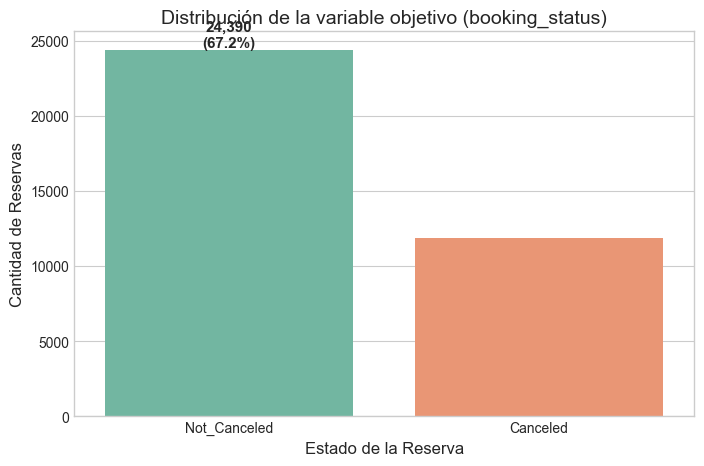

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

# Crear el gráfico de barras
ax = sns.countplot(x='booking_status', data=df_raw, palette=['#1f77b4', '#ff7f0e'], ax=ax)

# Personalización de textos
ax.set_title('Distribución de la variable objetivo (booking_status)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Estado de la Reserva', fontsize=12, fontweight='bold')
ax.set_ylabel('Cantidad de Reservas', fontsize=12, fontweight='bold')

# Obtener los valores de cada barra de forma robusta
for i, (categoria, valor) in enumerate(target_counts.items()):
    porcentaje = target_pct[categoria]
    # Colocar etiqueta centrada en la barra
    ax.text(i, valor + 500, f'{valor:,}\n({porcentaje:.1f}%)', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# Ajustar límites del eje Y para que las etiquetas sean visibles
ax.set_ylim(0, max(target_counts.values) * 1.1)

plt.tight_layout()
plt.savefig('../reports/distribucion_booking_status.png', dpi=150, bbox_inches='tight')
plt.show()

### Observaciones preliminares

> **[COMPLETAR CON TUS OBSERVACIONES]** — Responde aquí:
>
> - ¿Cuántas variables son numéricas vs. categóricas?
> - ¿Hay valores nulos?
> - ¿Cuál es la tasa de cancelación base del dataset?
> - ¿Hay algo sorprendente en los descriptivos (precios negativos, edades imposibles, etc.)?
> - ¿El dataset parece balanceado para el problema de clasificación?

---
## Sección 3 — Limpieza y Transformación (20%)

In [ ]:
# ── Copia de trabajo ───────────────────────────────────────────────────────────
# Siempre trabajamos sobre una copia para preservar el raw original
df = df_raw.copy()
print('Copia de trabajo creada.')

In [ ]:
# ── 3.1 Valores nulos ──────────────────────────────────────────────────────────
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({'count': nulos, 'pct': nulos_pct})
print('Variables con valores nulos:')
print(resumen_nulos[resumen_nulos['count'] > 0])
print('\nSi no se muestran filas: el dataset no tiene nulos.')

**Decisión sobre nulos:** [COMPLETAR] El dataset fue declarado por su autor como limpio. Si se encontraron nulos, describir la estrategia de tratamiento y justificarla.

In [ ]:
# ── 3.2 Duplicados ────────────────────────────────────────────────────────────
n_dup = df.duplicated().sum()
print(f'Filas duplicadas: {n_dup}')

if n_dup > 0:
    df = df.drop_duplicates()
    print(f'→ Eliminadas. Nuevo shape: {df.shape}')

In [ ]:
# ── 3.3 Corrección de tipos ────────────────────────────────────────────────────
# Verificar que booking_status sea categórica
print('Valores únicos en booking_status:', df['booking_status'].unique())
print('Valores únicos en market_segment_type:', df['market_segment_type'].unique())

# Convertir a categórica donde aplica
cat_cols = ['market_segment_type', 'type_of_meal_plan', 'room_type_reserved',
            'booking_status']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

In [ ]:
# ── 3.4 Revisión de rangos plausibles ─────────────────────────────────────────
print('Precio mínimo/máximo:', df['avg_price_per_room'].min(), '/', df['avg_price_per_room'].max())
print('Lead time mínimo/máximo:', df['lead_time'].min(), '/', df['lead_time'].max())
print('Peticiones especiales mín/máx:', df['no_of_special_requests'].min(), '/', df['no_of_special_requests'].max())

# Detectar precios = 0 (reservas gratuitas o error)
n_precio_cero = (df['avg_price_per_room'] == 0).sum()
print(f'\nReservas con precio = 0: {n_precio_cero} ({n_precio_cero/len(df)*100:.1f}%)')

**Decisión sobre precios = 0:** [COMPLETAR] ¿Son reservas complementarias (canal 'Complementary')? ¿Se mantienen o excluyen del análisis? Justificar.

In [ ]:
# ── 3.5 Join con tabla de comisiones OTA ──────────────────────────────────────
# Fuente: estimaciones de comisiones promedio de la industria hotelera
# (no son datos reales de ninguna plataforma específica)

ota_commissions = pd.DataFrame({
    'market_segment_type': ['Online', 'Offline', 'Corporate', 'Aviation', 'Complementary'],
    'ota_commission_pct':  [0.15,     0.10,      0.05,        0.08,       0.00],
    'channel_label':       ['OTA online', 'OTA offline', 'Corporativo', 'Aerolínea', 'Gratuito']
})

print('Tabla de comisiones OTA:')
print(ota_commissions)

# Merge tipo left para conservar todos los registros del dataset original
df = df.merge(ota_commissions, on='market_segment_type', how='left')

# Verificar que no haya nulos después del merge
print(f'\nNulos en ota_commission_pct tras merge: {df["ota_commission_pct"].isnull().sum()}')
print(f'Shape tras merge: {df.shape}')

In [ ]:
# ── 3.6 Feature Engineering ───────────────────────────────────────────────────
# Variables derivadas que enriquecen el análisis y sirven como base
# para modelos futuros (XGBoost, Random Forest)

# Variable objetivo numérica
df['is_canceled'] = (df['booking_status'] == 'Canceled').astype(int)

# Ingreso neto estimado del hotel por noche (precio - comisión del canal)
df['net_revenue_est'] = df['avg_price_per_room'] * (1 - df['ota_commission_pct'])

# Señal binaria de peticiones especiales
df['has_special_request'] = (df['no_of_special_requests'] > 0).astype(int)

# Categorías de antelación
df['lead_time_bin'] = pd.cut(
    df['lead_time'],
    bins=[-1, 7, 30, 90, df['lead_time'].max() + 1],
    labels=['misma_semana', '1_4_semanas', '1_3_meses', 'mas_3_meses']
)

# Total de huéspedes
df['total_guests'] = df['no_of_adults'] + df['no_of_children']

# Tercil de precio
df['price_tier'] = pd.qcut(
    df['avg_price_per_room'],
    q=3,
    labels=['precio_bajo', 'precio_medio', 'precio_alto'],
    duplicates='drop'
)

print('Features creadas:')
new_cols = ['is_canceled', 'net_revenue_est', 'has_special_request',
            'lead_time_bin', 'total_guests', 'price_tier']
print(df[new_cols].head())

In [ ]:
# ── 3.7 Guardar dataset limpio ────────────────────────────────────────────────
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/hotel_clean.csv', index=False)
print(f'Dataset limpio guardado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

### Resumen de transformaciones

| Transformación | Decisión | Justificación |
|---|---|---|
| Nulos | [COMPLETAR] | [COMPLETAR] |
| Duplicados | [COMPLETAR] | [COMPLETAR] |
| Precios = 0 | [COMPLETAR] | [COMPLETAR] |
| Join OTA | Left merge por `market_segment_type` | Permite calcular ingreso neto y analizar rentabilidad por canal |
| `is_canceled` | Encoding binario de `booking_status` | Necesario para el modelado estadístico |
| `net_revenue_est` | Precio × (1 - comisión) | Proxy de rentabilidad real para el hotel |
| `has_special_request` | Binarización de `no_of_special_requests` | Variable de señal de compromiso |
| `lead_time_bin` | Categorización en 4 grupos | Permite análisis por horizonte de reserva |
| `price_tier` | Tercil de precio | Permite segmentar el análisis por nivel de precio |

---
## Sección 4 — Análisis Exploratorio / EDA (20%)

### Visualización 1 — Distribución de peticiones especiales

In [ ]:
# Vas a necesitar RANDOM_SEED = 42 más adelante en la Sección 4 — el gráfico Plotly usa random_state=RANDOM_SEED (lo elimine arriba)
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    data=df,
    x='no_of_special_requests',
    hue='booking_status',
    multiple='dodge',
    discrete=True,
    ax=ax
)

ax.set_title('Distribución de peticiones especiales por estado de reserva',
             fontsize=13, pad=12)
ax.set_xlabel('Número de peticiones especiales')
ax.set_ylabel('Cantidad de reservas')
ax.legend(title='Estado', labels=['No cancelada', 'Cancelada'])
plt.tight_layout()
plt.savefig('../reports/viz1_distribucion_peticiones.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:** [COMPLETAR] ¿Cómo se distribuyen las peticiones especiales entre canceladas y no canceladas? ¿Se observa ya a simple vista alguna diferencia en la proporción?

### Visualización 2 — Tasa de cancelación por número de peticiones especiales

In [ ]:
cancel_by_requests = df.groupby('no_of_special_requests')['is_canceled'].mean().reset_index()
cancel_by_requests.columns = ['no_of_special_requests', 'cancel_rate']
cancel_by_requests['cancel_rate_pct'] = cancel_by_requests['cancel_rate'] * 100

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=cancel_by_requests,
    x='no_of_special_requests',
    y='cancel_rate_pct',
    ax=ax,
    color='#5DCAA5'
)

ax.set_title('Tasa de cancelación según número de peticiones especiales',
             fontsize=13, pad=12)
ax.set_xlabel('Número de peticiones especiales')
ax.set_ylabel('Tasa de cancelación (%)')
ax.axhline(df['is_canceled'].mean() * 100, color='coral', linestyle='--',
           label=f'Media global ({df["is_canceled"].mean()*100:.1f}%)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/viz2_tasa_cancelacion_peticiones.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:** [COMPLETAR] ¿Se observa una tendencia decreciente en la tasa de cancelación a medida que aumentan las peticiones especiales? ¿Es lineal o hay algún punto de inflexión?

### Visualización 3 — Distribución de precio por estado de cancelación

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

sns.kdeplot(
    data=df,
    x='avg_price_per_room',
    hue='booking_status',
    fill=True,
    alpha=0.4,
    ax=ax
)

ax.set_title('Distribución del precio promedio por habitación según estado de reserva',
             fontsize=13, pad=12)
ax.set_xlabel('Precio promedio por habitación (EUR/noche)')
ax.set_ylabel('Densidad')
plt.tight_layout()
plt.savefig('../reports/viz3_precio_cancelacion.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:** [COMPLETAR] ¿Las reservas canceladas tienden a tener precios más altos o más bajos? ¿Las distribuciones se solapan mucho o hay diferencias claras?

### Visualización 4 — Mapa de calor de correlaciones

In [ ]:
num_cols = ['is_canceled', 'no_of_special_requests', 'avg_price_per_room',
            'lead_time', 'no_of_adults', 'no_of_children',
            'no_of_weekend_nights', 'no_of_week_nights',
            'no_of_previous_cancellations', 'net_revenue_est']
num_cols = [c for c in num_cols if c in df.columns]

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    linewidths=0.5
)
ax.set_title('Mapa de correlaciones entre variables numéricas',
             fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('../reports/viz4_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:** [COMPLETAR] ¿Qué variables tienen mayor correlación con `is_canceled`? ¿Hay pares de variables predictoras con alta correlación entre sí (multicolinealidad potencial)? ¿Qué implica esto para el modelado?

### Visualización 5 — Gráfico interactivo (Plotly)

In [ ]:
fig_plotly = px.scatter(
    df.sample(n=5000, random_state=RANDOM_SEED),  # muestra para rendimiento
    x='lead_time',
    y='avg_price_per_room',
    color='booking_status',
    size='no_of_special_requests',
    size_max=12,
    hover_data=['market_segment_type', 'no_of_special_requests',
                'net_revenue_est', 'total_guests'],
    color_discrete_map={'Canceled': '#E24B4A', 'Not_Canceled': '#1D9E75'},
    labels={
        'lead_time': 'Antelación de la reserva (días)',
        'avg_price_per_room': 'Precio promedio por habitación (EUR/noche)',
        'booking_status': 'Estado de la reserva',
        'no_of_special_requests': 'Peticiones especiales'
    },
    title='Relación entre antelación, precio y cancelación<br><sup>Tamaño del punto = número de peticiones especiales (muestra de 5,000 reservas)</sup>'
)

fig_plotly.update_layout(
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    height=500
)

fig_plotly.show()

**Interpretación:** [COMPLETAR] Explorar el gráfico interactivo. ¿Se forman clusters visibles de canceladas vs. no canceladas? ¿Las reservas con puntos más grandes (más peticiones especiales) tienden a estar más en el grupo de no canceladas?

---
## Sección 5 — Análisis Estadístico y Modelado (20%)

### 5.1 Prueba de independencia Chi-cuadrado

**Hipótesis:**
- H₀: El segmento de mercado (`market_segment_type`) y el estado de cancelación son independientes
- H₁: Existe dependencia estadística entre el segmento de mercado y la cancelación
- Nivel de significancia: α = 0.05

In [ ]:
# Tabla de contingencia
contingency = pd.crosstab(
    df['market_segment_type'],
    df['booking_status'],
    margins=True
)
print('Tabla de contingencia:')
print(contingency)

# Tasas de cancelación por segmento
print('\nTasas de cancelación por segmento:')
cancel_by_segment = df.groupby('market_segment_type')['is_canceled'].mean() * 100
print(cancel_by_segment.sort_values(ascending=False).round(1))

In [ ]:
# Chi-cuadrado
contingency_clean = pd.crosstab(df['market_segment_type'], df['booking_status'])

chi2, p_valor, gl, esperados = stats.chi2_contingency(contingency_clean)

print('── Resultados Chi-cuadrado ──────────────────')
print(f'Estadístico χ²:  {chi2:.4f}')
print(f'p-valor:         {p_valor:.6f}')
print(f'Grados libertad: {gl}')
print(f'\nDecisión (α=0.05): {"Rechazar H₀" if p_valor < 0.05 else "No rechazar H₀"}')

# Verificar supuesto: frecuencias esperadas ≥ 5
pct_menor_5 = (esperados < 5).sum() / esperados.size * 100
print(f'\nCelda con frecuencia esperada < 5: {pct_menor_5:.1f}% (supuesto OK si < 20%)')

**Interpretación:** [COMPLETAR] ¿Se rechaza H₀? ¿Qué implica esto sobre la relación entre el canal de reserva y la cancelación? ¿Qué segmentos tienen tasas de cancelación significativamente distintas de la media?

### 5.2 Regresión Logística

**Variable dependiente:** `is_canceled`  
**Variables independientes:** `no_of_special_requests`, `avg_price_per_room`, `lead_time`

In [ ]:
# Preparar datos para el modelo
model_cols = ['no_of_special_requests', 'avg_price_per_room', 'lead_time']
df_model = df[model_cols + ['is_canceled']].dropna()

X = sm.add_constant(df_model[model_cols])  # añadir intercepto
y = df_model['is_canceled']

print(f'Observaciones en el modelo: {len(df_model):,}')
print(f'Variables: {model_cols}')

In [ ]:
# Ajustar modelo logístico
logit_model = sm.Logit(y, X)
resultado = logit_model.fit(maxiter=200, disp=False)

print(resultado.summary())

In [ ]:
# Odds ratios con intervalos de confianza al 95%
odds_ratios = pd.DataFrame({
    'Odds Ratio':    np.exp(resultado.params),
    'IC 95% inf':   np.exp(resultado.conf_int()[0]),
    'IC 95% sup':   np.exp(resultado.conf_int()[1]),
    'p-valor':      resultado.pvalues
}).round(4)

print('Odds Ratios (exp(coef)):')
print(odds_ratios)

print(f'\nPseudo R² (McFadden): {resultado.prsquared:.4f}')
print(f'AIC: {resultado.aic:.2f}')

### Interpretación del modelo

> **[COMPLETAR — Guía de interpretación]**
>
> Para cada variable significativa (p < 0.05), responder:
>
> - **`no_of_special_requests`**: Un OR < 1 indicaría que cada petición especial adicional *reduce* el odds de cancelación en [X]%. ¿Qué dice tu modelo?
> - **`avg_price_per_room`**: ¿Más precio aumenta o reduce la probabilidad de cancelar?
> - **`lead_time`**: ¿A mayor antelación, más riesgo?
> - **Pseudo R²**: ¿El modelo explica bien la varianza? (Valores > 0.20 son razonables en logística)
> - **Limitación**: Este modelo no incluye variables categóricas. Una versión más completa incluiría `market_segment_type` como dummy.

---
## Sección 6 — Uso de IA Documentado (5%)

### Herramienta utilizada: Claude (Anthropic) + Claude Code

A continuación se documenta de forma reflexiva el uso de inteligencia artificial en este proyecto.

| Momento | Qué se solicitó | Qué entregó la IA | Ajuste manual realizado |
|---|---|---|---|
| Definición del proyecto | [COMPLETAR] | [COMPLETAR] | [COMPLETAR] |
| Sección 3 — Limpieza | [COMPLETAR] | [COMPLETAR] | [COMPLETAR] |
| Sección 4 — EDA | [COMPLETAR] | [COMPLETAR] | [COMPLETAR] |
| Sección 5 — Modelado | [COMPLETAR] | [COMPLETAR] | [COMPLETAR] |
| README | [COMPLETAR] | [COMPLETAR] | [COMPLETAR] |

### Reflexión crítica

> **[COMPLETAR]** Responde:
> - ¿En qué momentos la IA fue más útil?
> - ¿Cometió errores o generó código que no funcionó directamente? ¿Cuáles?
> - ¿Qué partes del análisis requirieron mayor intervención tuya?
> - ¿Cambiarías algo de cómo usaste la IA en un próximo proyecto?

### Ejemplo concreto de uso y ajuste

> **[COMPLETAR]** Describe un caso específico: qué prompt usaste, qué código/texto generó la IA, y qué tuviste que corregir o mejorar para que fuera correcto.

---
## Sección 7 — Conclusiones (10%)

### Respuesta a la pregunta de análisis

> **¿Existe una relación de dependencia estadística entre el número de peticiones especiales y la probabilidad de cancelación?**

[COMPLETAR] Responder directamente, con referencia a los resultados de la Sección 5:
- La prueba Chi-cuadrado mostró que...
- La regresión logística indica que cada petición especial adicional...
- El precio actúa como moderador en el sentido de que...

### Hallazgos principales

1. [COMPLETAR]
2. [COMPLETAR]
3. [COMPLETAR]

### Limitaciones y sesgos del análisis

- **Causalidad vs. correlación:** El análisis es observacional. No podemos afirmar que las peticiones especiales *causan* menor cancelación — podría haber variables confusoras (tipo de viajero, propósito del viaje).
- **Dataset sintético:** El origen exacto de los datos no está completamente documentado. Los patrones encontrados pueden no generalizar a cualquier hotel.
- **Variables omitidas:** No se consideraron el historial del huésped, la temporada exacta, ni las condiciones del contrato de cancelación.
- **Modelo simple:** La regresión logística con 3 variables es un modelo de base. Un modelo más robusto incluiría variables categóricas y posiblemente interacciones.

### Recomendación de negocio

[COMPLETAR] Basado en los hallazgos, ¿qué recomendarías a un hotel para reducir cancelaciones? Por ejemplo: ¿Incentivar al momento de reservar que el huésped especifique peticiones? ¿Segmentar la política de cancelación por canal?

### Próximos pasos (Feature Engineering para modelos futuros)

Las variables creadas en la Sección 3 (`lead_time_bin`, `price_tier`, `has_special_request`, `net_revenue_est`) están diseñadas para alimentar modelos de mayor complejidad en iteraciones futuras:

- Regresión Logística con variables dummy de segmento de mercado
- Random Forest para ranking de importancia de variables
- XGBoost para predicción en producción